In [112]:
import cv2 as cv
import numpy as np
import matplotlib.pyplot as plt

img_path = "assets/tray8.jpg"

Tray area: 194100.0


(np.float64(-0.5), np.float64(749.5), np.float64(999.5), np.float64(-0.5))

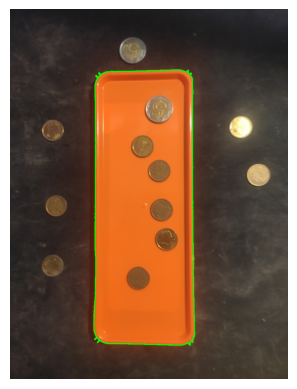

In [113]:
img = cv.imread(img_path)
imgray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

_, thresh = cv.threshold(imgray, 100, 255, cv.THRESH_BINARY)

contours, hierarchy = cv.findContours(thresh, cv.RETR_TREE, cv.CHAIN_APPROX_SIMPLE)
#tray = largest contour
tray = max(contours, key=cv.contourArea)

#area
area = cv.contourArea(tray)
print("Tray area:", area)

#draw tray
cv.drawContours(img, [tray], -1 , (0,255,0), 2)

img_rgb = cv.cvtColor(img, cv.COLOR_BGR2RGB)

plt.imshow(img_rgb)
plt.axis("off")

(np.float64(-0.5), np.float64(749.5), np.float64(999.5), np.float64(-0.5))

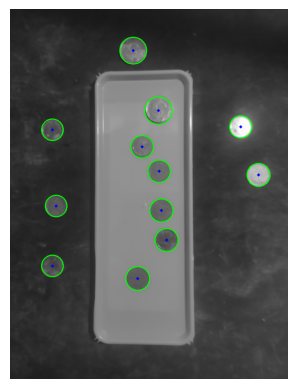

In [114]:
img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)

img = cv.medianBlur(img,5)
cimg = cv.cvtColor(img,cv.COLOR_GRAY2BGR)

circles = cv.HoughCircles(img,method = cv.HOUGH_GRADIENT,dp = 1,minDist = 40,param1=100,param2=40,minRadius=20,maxRadius=80)

circles = np.uint16(np.around(circles))

for i in circles[0,:]:
    # draw the outer circle
    cv.circle(cimg,(i[0],i[1]),i[2],(0,255,0),2)
    # draw the center of the circle
    cv.circle(cimg,(i[0],i[1]),2,(0,0,255),3)

plt.imshow(cimg)
plt.axis("off")

In [115]:
big_in = small_in = big_out = small_out = 0
R_SPLIT = 35

if circles is not None:
    circles = np.uint16(np.around(circles))

    for x, y, r in circles[0, :]:

        inside = cv.pointPolygonTest(tray, (int(x), int(y)), False) >= 0

        if r > R_SPLIT:
            size = "big"
            color = (255,0,0)
        else:
            size = "small"
            color = (0,0,255)

        if inside:
            if size == "big":
                big_in += 1
            else:
                small_in += 1
        else:
            if size == "big":
                big_out += 1
            else:
                small_out += 1

        # draw
        cv.circle(cimg, (x,y), r, color, 2)
        cv.circle(cimg, (x,y), 2, (0,255,255), 3)


print("Big in tray:", big_in)
print("Small in tray:", small_in)
print("Big out:", big_out)
print("Small out:", small_out)


Big in tray: 1
Small in tray: 5
Big out: 1
Small out: 5
